In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)

In [2]:
# load dataset
df = pd.read_csv("ai4i2020.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (10000, 14)
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0  

In [3]:
# Processing Data

# Drop unnecessary ID columns
df = df.drop(columns=["UDI", "Product ID"])

# Encode categorical feature
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])

# Separate features and target
X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# Train-Test-Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Unscaled version for Random Forest
X_train_raw, X_test_raw, _, _ = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nTraining samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Failure rate: {y.mean():.2%}")



Training samples: 8000
Test samples: 2000
Failure rate: 3.39%


In [5]:
# 5. Logistic Regression (balanced and scaled)

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_lr))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [6]:
# 6. Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_raw, y_train)

y_pred_rf = rf.predict(X_test_raw)

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))


--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [7]:
# 7. Cross Validation

print("\n--- Cross Validation ---")

cv_lr = cross_val_score(
    lr,
    X_scaled,
    y,
    cv=5,
    scoring='recall'
)

print(f"Logistic Regression Recall: {cv_lr.mean():.3f} ± {cv_lr.std():.3f}")

cv_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='recall'
)

print(f"Random Forest Recall: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")



--- Cross Validation ---
Logistic Regression Recall: 0.973 ± 0.019
Random Forest Recall: 0.968 ± 0.022


In [8]:
# 8. Precision Recall Threshold

y_prob_rf = rf.predict_proba(X_test_raw)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_rf
)

# Calculate F1 score
f1_scores = (
    2 * (precision[:-1] * recall[:-1]) /
    (precision[:-1] + recall[:-1] + 1e-9)
)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest Threshold: {best_threshold:.3f}")
print(f"Best F1 Score: {f1_scores[best_idx]:.3f}")


Best Threshold: 0.490
Best F1 Score: 0.985


In [9]:
# Apply best threshold
y_pred_rf_best = (y_prob_rf >= best_threshold).astype(int)

print("\n--- Random Forest (Best Threshold) ---")
print(classification_report(y_test, y_pred_rf_best))



--- Random Forest (Best Threshold) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



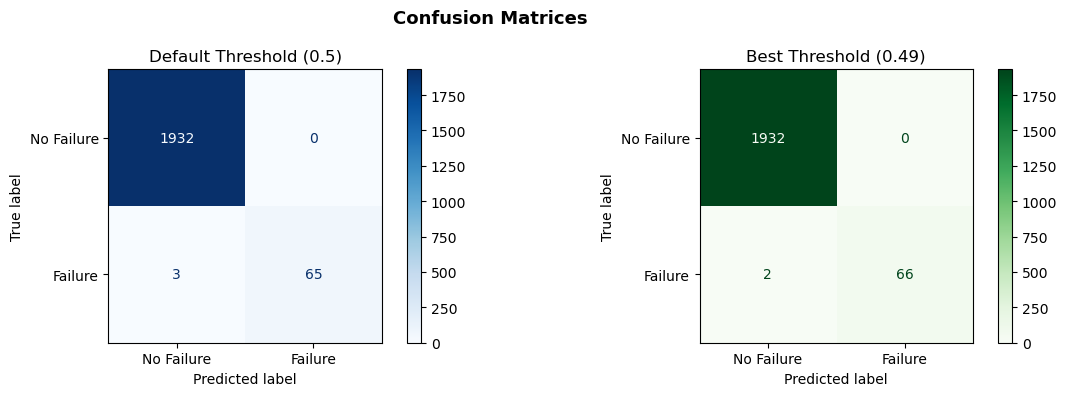

Saved: confusion_matrices.png


In [10]:
# 9. Confusion Matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    ax=axes[0],
    display_labels=["No Failure", "Failure"],
    cmap="Blues"
)

axes[0].set_title("Default Threshold (0.5)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_best,
    ax=axes[1],
    display_labels=["No Failure", "Failure"],
    cmap="Greens"
)

axes[1].set_title(f"Best Threshold ({best_threshold:.2f})")

plt.suptitle(
    "Confusion Matrices",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "confusion_matrices.png",
    dpi=150
)

plt.show()

print("Saved: confusion_matrices.png")


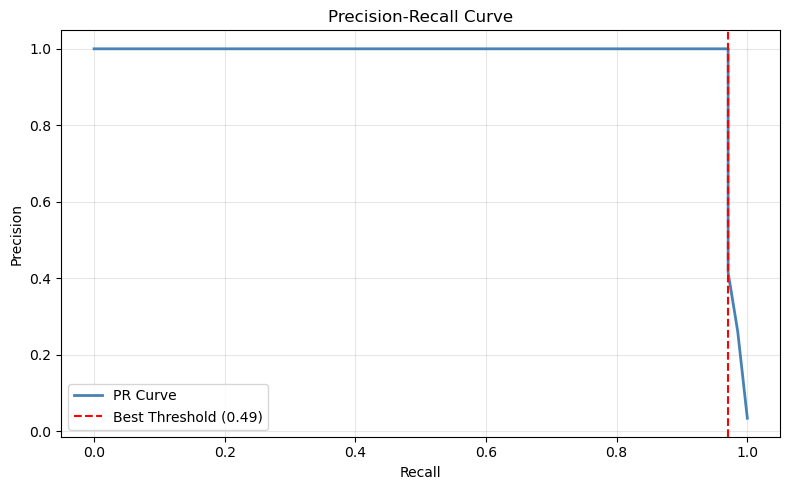

Saved: precision_recall_curve.png


In [11]:
# 10. Precision Recall Curve

plt.figure(figsize=(8, 5))

plt.plot(
    recall,
    precision,
    color='steelblue',
    linewidth=2,
    label='PR Curve'
)

plt.axvline(
    recall[best_idx],
    color='red',
    linestyle='--',
    label=f'Best Threshold ({best_threshold:.2f})'
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "precision_recall_curve.png",
    dpi=150
)

plt.show()

print("Saved: precision_recall_curve.png")

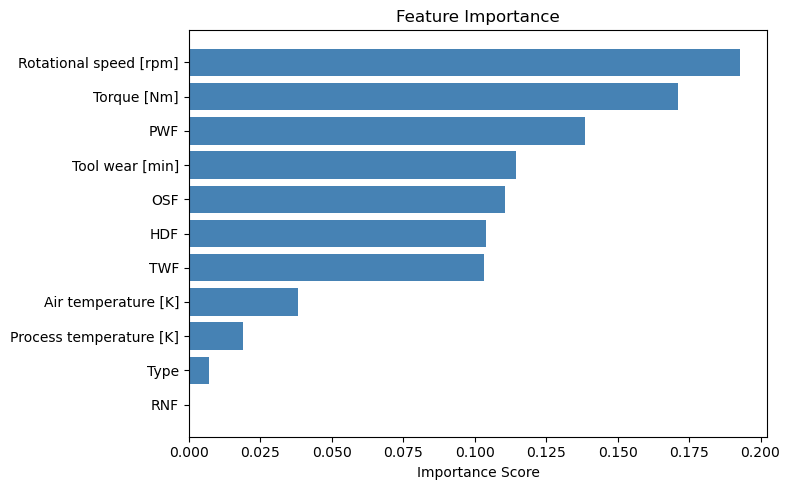

Saved: feature_importance.png


In [12]:
# 11. Feature Importance

importances = rf.feature_importances_

features = X.columns

sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 5))

plt.barh(
    features[sorted_idx],
    importances[sorted_idx],
    color='steelblue'
)

plt.xlabel("Importance Score")

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=150
)

plt.show()

print("Saved: feature_importance.png")


In [13]:
# 12. Save Final Output

output_df = X_test_raw.copy()

output_df["Actual_Failure"] = y_test.values

output_df["Predicted_Failure_Default"] = y_pred_rf

output_df["Predicted_Failure_BestThresh"] = y_pred_rf_best

output_df["Failure_Probability"] = y_prob_rf

output_df.to_csv(
    "final_output.csv",
    index=False
)

print("\nSaved: final_output.csv")

print("\nDone!")


Saved: final_output.csv

Done!


In [14]:
# Project Summary

# Built a Machine Failure Prediction system using the
# AI4I 2020 Predictive Maintenance dataset.

# Objective:
# Predict machine failures early using industrial sensor data
# to reduce downtime and maintenance costs.

# Models Used:
# - Logistic Regression
# - Random Forest Classifier

# Key Improvements:
# - Feature scaling using StandardScaler
# - Handled class imbalance using class_weight='balanced'
# - Used 5-fold Cross Validation for reliable evaluation
# - Optimized prediction threshold using Precision-Recall Curve
# - Prevented data leakage by evaluating only on unseen test data

# Evaluation Metrics:
# - Recall
# - Precision
# - F1 Score
# - Confusion Matrix

# Best Model:
# Random Forest with optimized threshold achieved the best balance
# between detecting failures and reducing false alarms.